In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector, RFE, f_classif, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [2]:
X,y=fetch_openml(name='madelon',version=1,as_frame=False,return_X_y=True)
y=y.astype(int)

In [3]:
X.shape

(2600, 500)

In [4]:
y.shape

(2600,)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [6]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [7]:
logreg=LogisticRegression(max_iter=1000)
dtree=DecisionTreeClassifier(random_state=42)

In [8]:
logreg.fit(X_train_scaled,y_train)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
print(f"Logistic Regression: {logreg.score(X_test_scaled,y_test)*100:.2f}%")
print(f"Decision Tree: {dtree.score(X_test,y_test)*100:.2f}%")

Logistic Regression: 52.18%
Decision Tree: 71.67%


In [10]:
sfs_forward=SequentialFeatureSelector(LogisticRegression(max_iter=1000),
                                      n_features_to_select=25,
                                      direction='forward')

In [11]:
sfs_forward.fit(X_train_scaled,y_train)
X_train_fwd=sfs_forward.transform(X_train_scaled)
X_test_fwd=sfs_forward.transform(X_test_scaled)

In [12]:
logreg_forward=LogisticRegression(max_iter=1000)
logreg_forward.fit(X_train_fwd,y_train)
print(f"Logistic Regression: {logreg_forward.score(X_test_fwd,y_test)*100:.2f}%")

Logistic Regression: 60.38%


In [13]:
sfs_backward=SequentialFeatureSelector(LogisticRegression(max_iter=1000),
                                      n_features_to_select=25,
                                      direction='backward')

In [14]:
sfs_backward.fit(X_train_scaled,y_train)
X_train_bwd=sfs_backward.transform(X_train_scaled)
X_test_bwd=sfs_backward.transform(X_test_scaled)

KeyboardInterrupt: 

In [ ]:
logreg_backward=LogisticRegression(max_iter=1000)
logreg_backward.fit(X_train_bwd,y_train)
print(f"Logistic Regression: {logreg_forward.score(X_test_bwd,y_test)*100:.2f}%")

In [ ]:
sfs_forward=SequentialFeatureSelector(DecisionTreeClassifier(random_state=42),
                                      n_features_to_select=25,
                                      direction='forward')

In [ ]:
sfs_forward.fit(X_train,y_train)
X_train_fwd=sfs_forward.transform(X_train)
X_test_fwd=sfs_forward.transform(X_test)

In [ ]:
dtree_forward=DecisionTreeClassifier(random_state=42)
dtree_forward.fit(X_train_fwd,y_train)
print(f"Decision Tree: {dtree_forward.score(X_test_fwd,y_test)*100:.2f}%")

In [16]:
for k in [10,20,25,30]:
  selector=SelectKBest(score_func=f_classif,k=k)
  X_train_Kbest=selector.fit_transform(X_train_scaled,y_train)
  X_test_Kbest=selector.transform(X_test_scaled)

  logreg_kbest=LogisticRegression(max_iter=1000)
  logreg_kbest.fit(X_train_Kbest,y_train)
  print(f"Accuracy with K={k} is {logreg_kbest.score(X_test_Kbest,y_test)*100:.2f}%")

Accuracy with K=10 is 62.05%
Accuracy with K=20 is 61.28%
Accuracy with K=25 is 59.74%
Accuracy with K=30 is 59.49%


In [17]:
for k in [10,20,25,30]:
  selector=SelectKBest(score_func=f_classif,k=k)
  X_train_Kbest=selector.fit_transform(X_train,y_train)
  X_test_Kbest=selector.transform(X_test)

  dtree_kbest=DecisionTreeClassifier(random_state=42)
  dtree_kbest.fit(X_train_Kbest,y_train)
  print(f"Accuracy with K={k} is {dtree_kbest.score(X_test_Kbest,y_test)*100:.2f}%")

Accuracy with K=10 is 78.08%
Accuracy with K=20 is 75.51%
Accuracy with K=25 is 74.10%
Accuracy with K=30 is 74.74%


In [18]:
rfe=RFE(
    estimator=LogisticRegression(max_iter=1000),
    n_features_to_select=15
)
rfe.fit(X_train_scaled,y_train)
X_train_rfe=rfe.transform(X_train_scaled)
X_test_rfe=rfe.transform(X_test_scaled)
logreg_rfe=LogisticRegression(max_iter=1000)
logreg_rfe.fit(X_train_rfe,y_train)
print(f"Accuracy: {logreg_rfe.score(X_test_rfe,y_test)*100:.2f}%")

Accuracy: 60.38%


In [19]:
rfe=RFE(
    estimator=DecisionTreeClassifier(random_state=42),
    n_features_to_select=15
)
rfe.fit(X_train_scaled,y_train)
X_train_rfe=rfe.transform(X_train)
X_test_rfe=rfe.transform(X_test)
dtree_rfe=DecisionTreeClassifier(random_state=42)
dtree_rfe.fit(X_train_rfe,y_train)
print(f"Accuracy: {dtree_rfe.score(X_test_rfe,y_test)*100:.2f}%")

Accuracy: 76.92%


In [24]:
l2=LogisticRegression(penalty='l2',max_iter=1000)
l2.fit(X_train_scaled,y_train)
selected_features=np.where(l2.coef_[0]!=0)[0]
X_train_l2=X_train_scaled[:,selected_features]
X_test_l2=X_test_scaled[:,selected_features]

In [25]:
logreg_l2=LogisticRegression(max_iter=1000)
logreg_l2.fit(X_train_l2,y_train)
print(f"Accuracy: {logreg_l2.score(X_test_l2,y_test)*100:.2f}%")

Accuracy: 52.18%


In [41]:
pca=PCA(n_components=25,random_state=42)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)


In [34]:
logreg_pca=LogisticRegression(max_iter=1000)
logreg_pca.fit(X_train_pca,y_train)

LogisticRegression(max_iter=1000)

In [35]:
print(f"Accuracy: {logreg_pca.score(X_test_pca,y_test)*100:.2f}%")

Accuracy: 61.54%


In [42]:
dtree_pca=DecisionTreeClassifier(random_state=42)
dtree_pca.fit(X_train_pca,y_train)
print(f"Accuracy: {dtree_pca.score(X_test_pca,y_test)*100:.2f}%")

Accuracy: 70.00%


In [44]:
np.argsort(dtree.feature_importances_)[-25:]

array([486,  31, 451, 472, 126, 108,   8, 303, 241, 128, 281,  41, 435,
       455, 493,  28, 433,  48, 153, 442, 318, 105, 378, 475, 338])

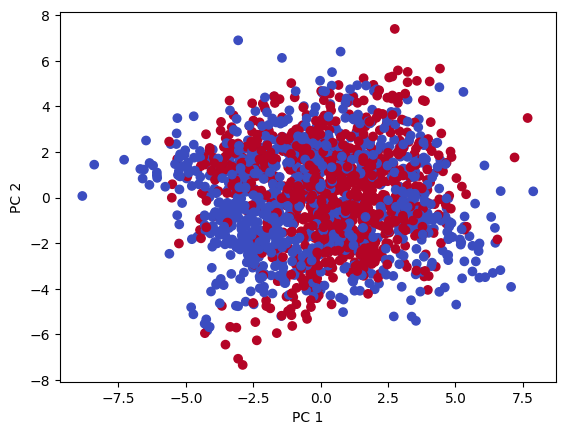

In [47]:
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train,cmap="coolwarm")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()